In [1]:
import os
import warnings
from pathlib import Path
from datetime import datetime
import subprocess

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

print("Current working directory:", Path.cwd())
print("Files in current directory:")
for p in Path.cwd().iterdir():
    print(" -", p.name)

Current working directory: C:\Users\bruce\Desktop\workshop
Files in current directory:
 - .ipynb_checkpoints
 - outputs
 - sample_submission.csv
 - Spaceship(3) (5)(2).ipynb
 - test.csv
 - train.csv


In [2]:
# BLOCK 00 | Install optional packages if missing
import sys
import subprocess

def ensure_package(pkg_name, import_name=None):
    import_name = import_name or pkg_name
    try:
        __import__(import_name)
        print(f'{pkg_name} already installed.')
    except ImportError:
        print(f'Installing {pkg_name} ...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pkg_name])

ensure_package('catboost')
ensure_package('lightgbm')

catboost already installed.
lightgbm already installed.


In [3]:
# BLOCK 01 | Imports and setup

from __future__ import annotations

from typing import Any

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder

try:
    from sklearn.model_selection import StratifiedGroupKFold
    SGKF_AVAILABLE = True
except Exception:
    SGKF_AVAILABLE = False

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False

try:
    from catboost import CatBoostClassifier
    CAT_AVAILABLE = True
except Exception:
    CAT_AVAILABLE = False

plt.style.use('dark_background')
sns.set_theme(style='darkgrid', context='talk')
plt.rcParams.update({
    'figure.facecolor': '#0e1117',
    'axes.facecolor': '#0e1117',
    'savefig.facecolor': '#0e1117',
    'axes.edgecolor': '#9ca3af',
    'axes.labelcolor': '#e5e7eb',
    'xtick.color': '#d1d5db',
    'ytick.color': '#d1d5db',
    'grid.color': '#374151',
    'text.color': '#f3f4f6'
})

pd.set_option('display.max_rows', 20)
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 180)
pd.options.display.float_format = '{:,.5f}'.format

print('Libraries loaded.')
print(f'StratifiedGroupKFold available: {SGKF_AVAILABLE}')
print(f'XGBoost available: {XGB_AVAILABLE}')
print(f'LightGBM available: {LGB_AVAILABLE}')
print(f'CatBoost available: {CAT_AVAILABLE}')

Libraries loaded.
StratifiedGroupKFold available: True
XGBoost available: False
LightGBM available: True
CatBoost available: True


In [4]:
# BLOCK 02 | Configuration

class CFG:
    competition_name = 'spaceship-titanic'

    project_root = Path.cwd()
    input_root = project_root
    input_dir = None

    output_dir = project_root / 'outputs'
    output_dir.mkdir(parents=True, exist_ok=True)

    target = 'Transported'
    cpu_threads = max(1, (os.cpu_count() or 4) - 2)

    # 先减少 seed，保证速度和稳定性
    random_seeds = [42]
    n_splits = 5
    use_group_cv = False   # 关键：不用 group cv

    submission_file = output_dir / 'submission_push_082.csv'
    enable_auto_submit = False
    submission_message = None

    use_pseudo_label = False
    blend_trials = 0

    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

    categorical_cols = [
        'HomePlanet', 'CryoSleep', 'Destination', 'VIP',
        'CabinDeck', 'CabinSide',
        'HomeDest', 'DeckSide', 'CabinZone', 'AgeBand',
        'Surname', 'CabinKey',
        'SurnameHome', 'SurnameDest',
        'DeckDest', 'DeckHome', 'SideDest'
    ]

    feature_cols = [
        # base cat
        'HomePlanet', 'CryoSleep', 'Destination', 'VIP',
        'CabinDeck', 'CabinSide',
        'HomeDest', 'DeckSide', 'CabinZone', 'AgeBand',
        'Surname', 'CabinKey',
        'SurnameHome', 'SurnameDest',
        'DeckDest', 'DeckHome', 'SideDest',

        # ids / group
        'GroupId', 'GroupMember', 'GroupSize', 'Solo',
        'SurnameSize',

        # numeric base
        'Age', 'CabinNum', 'CabinBucket100', 'CabinNumPerDeck',
        'CryoFlag', 'VipFlag',
        'SpendPositiveCount', 'NoSpend',

        # spend raw
        'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
        'TotalSpend', 'AvgSpendPerService', 'SpendPerGroupMember',
        'LuxurySpend', 'BaseSpend', 'LuxuryShare', 'ServiceStd',

        # log
        'Log_RoomService', 'Log_FoodCourt', 'Log_ShoppingMall', 'Log_Spa', 'Log_VRDeck',
        'Log_TotalSpend', 'Log_AvgSpendPerService', 'Log_SpendPerGroupMember',

        # strong interactions
        'AgeSpendInteraction',
        'CryoNoSpend', 'NoCryoNoSpend',

        # occupancy / family
        'CabinOccupancy', 'ExactCabinMates',

        # group aggregates
        'GroupSpendMean', 'GroupSpendMax', 'GroupSpendMin',
        'GroupAgeMean', 'GroupAgeStd',
        'SpendShareInGroup', 'AgeDiffFromGroupMean',
        'GroupNoSpendRate', 'GroupCryoRate', 'GroupHasVIP',
        'AgeRankInGroup', 'IsGroupMaxSpender',

        # deck-level
        'CabinNumZDeck',
        'DeckCryoRate',
        'SpendRankInPlanet', 'SpendRankInDeck',
    ]

In [5]:
# BLOCK 03 | Load train, test, and sample submission

def discover_competition_input_dir() -> Path:
    required_files = {'train.csv', 'test.csv', 'sample_submission.csv'}

    candidate_dirs = [
        Path.cwd(),                              # notebook 同目录
        Path.cwd() / 'data',                     # ./data
        Path.cwd() / 'data' / 'spaceship-titanic',  # ./data/spaceship-titanic
        Path.cwd() / 'spaceship-titanic',        # ./spaceship-titanic
        Path('/kaggle/input/competitions/spaceship-titanic'),
        Path('/kaggle/input/spaceship-titanic'),
    ]

    for p in candidate_dirs:
        if p.exists() and p.is_dir():
            files = {x.name for x in p.iterdir() if x.is_file()}
            if required_files.issubset(files):
                return p

    raise FileNotFoundError(
        "找不到数据目录。\n"
        "请确认以下 3 个文件存在于以下任一目录：\n"
        "1. notebook 同目录\n"
        "2. ./data/\n"
        "3. ./data/spaceship-titanic/\n"
        "文件必须包括: train.csv, test.csv, sample_submission.csv"
    )

CFG.input_dir = discover_competition_input_dir()

train_df = pd.read_csv(CFG.input_dir / 'train.csv')
test_df = pd.read_csv(CFG.input_dir / 'test.csv')
sample_submission = pd.read_csv(CFG.input_dir / 'sample_submission.csv')

y = train_df[CFG.target].astype(int)

print('Resolved input directory:', CFG.input_dir.resolve())
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)
print('Sample submission shape:', sample_submission.shape)

display(train_df.head())

Resolved input directory: C:\Users\bruce\Desktop\workshop
Train shape: (8693, 14)
Test shape: (4277, 13)
Sample submission shape: (4277, 2)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.00000,False,0.00000,0.00000,0.00000,0.00000,0.00000,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.00000,False,109.00000,9.00000,25.00000,549.00000,44.00000,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.00000,True,43.00000,"3,576.00000",0.00000,"6,715.00000",49.00000,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.00000,False,0.00000,"1,283.00000",371.00000,"3,329.00000",193.00000,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.00000,False,303.00000,70.00000,151.00000,565.00000,2.00000,Willy Santantines,True


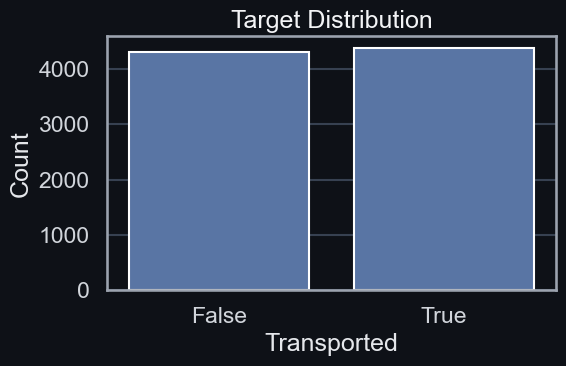

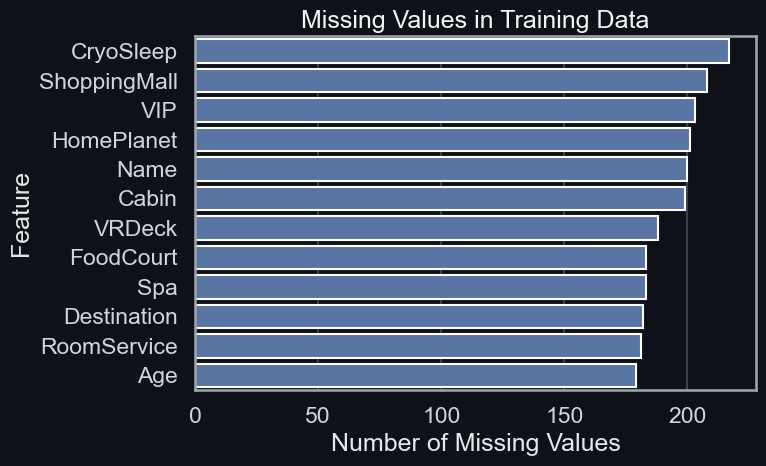

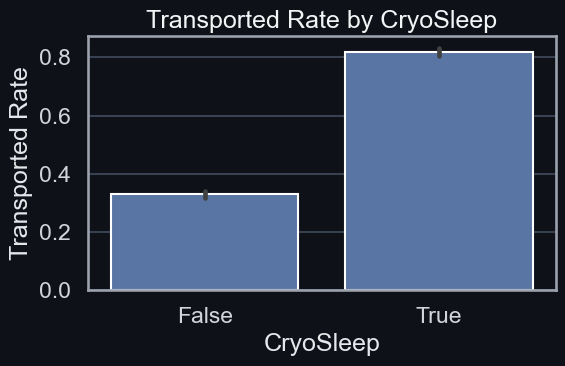

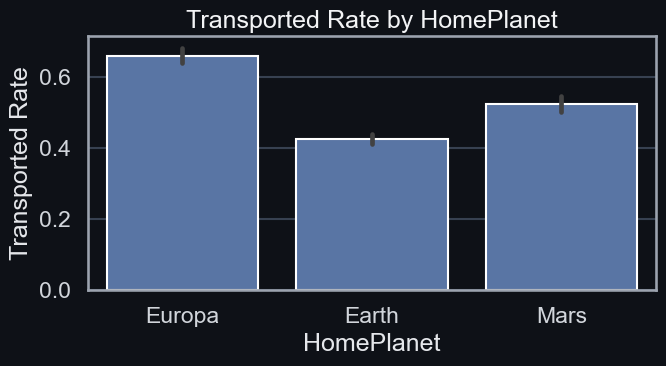

In [30]:
# BLOCK 03.5 | EDA Visualizations for PPT

import matplotlib.pyplot as plt
import seaborn as sns

eda_dir = CFG.output_dir / "eda_figures"
eda_dir.mkdir(parents=True, exist_ok=True)

# 1. Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x="Transported")
plt.title("Target Distribution")
plt.xlabel("Transported")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(eda_dir / "target_distribution.png", dpi=300)
plt.show()

# 2. Missing values
missing = train_df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=missing.values, y=missing.index)
plt.title("Missing Values in Training Data")
plt.xlabel("Number of Missing Values")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(eda_dir / "missing_values.png", dpi=300)
plt.show()

# 3. CryoSleep vs Transported
plt.figure(figsize=(6, 4))
sns.barplot(data=train_df, x="CryoSleep", y=train_df["Transported"].astype(int))
plt.title("Transported Rate by CryoSleep")
plt.xlabel("CryoSleep")
plt.ylabel("Transported Rate")
plt.tight_layout()
plt.savefig(eda_dir / "cryosleep_vs_transported.png", dpi=300)
plt.show()

# 4. HomePlanet vs Transported
plt.figure(figsize=(7, 4))
sns.barplot(data=train_df, x="HomePlanet", y=train_df["Transported"].astype(int))
plt.title("Transported Rate by HomePlanet")
plt.xlabel("HomePlanet")
plt.ylabel("Transported Rate")
plt.tight_layout()
plt.savefig(eda_dir / "homeplanet_vs_transported.png", dpi=300)
plt.show()

In [6]:
# BLOCK 04 | Feature Engineering

def engineer_features(train_df: pd.DataFrame, test_df: pd.DataFrame):
    train = train_df.copy()
    test = test_df.copy()

    train['_is_train'] = 1
    test['_is_train'] = 0

    full = pd.concat([train, test], axis=0, ignore_index=True)

    # 1. Basic cleanup
    for col in ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']:
        if col in full.columns:
            full[col] = full[col].astype('object')

    if 'Age' in full.columns:
        full['Age'] = pd.to_numeric(full['Age'], errors='coerce')

    spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
    for col in spend_cols:
        full[col] = pd.to_numeric(full[col], errors='coerce')

    # 2. PassengerId parsing
    pid_split = full['PassengerId'].astype(str).str.split('_', expand=True)
    full['GroupId'] = pd.to_numeric(pid_split[0], errors='coerce').fillna(-1).astype(int)
    full['GroupMember'] = pd.to_numeric(pid_split[1], errors='coerce').fillna(-1).astype(int)

    full['GroupSize'] = full.groupby('GroupId')['PassengerId'].transform('size').astype(int)
    full['Solo'] = (full['GroupSize'] == 1).astype(int)

    # 3. Name parsing
    name_split = full['Name'].fillna('Unknown Unknown').astype(str).str.strip().str.split(' ', n=1, expand=True)
    full['FirstName'] = name_split[0].fillna('Unknown').replace('', 'Unknown')
    full['Surname'] = name_split[1].fillna('Unknown').replace('', 'Unknown')

    # 4. Cabin parsing
    cabin_split = full['Cabin'].fillna('Unknown/Unknown/Unknown').astype(str).str.split('/', expand=True)
    full['CabinDeck'] = cabin_split[0].fillna('Unknown').replace('', 'Unknown')
    full['CabinNum'] = pd.to_numeric(cabin_split[1], errors='coerce')
    full['CabinSide'] = cabin_split[2].fillna('Unknown').replace('', 'Unknown')

    # 5. Normalize bool-like columns
    def normalize_bool_str(x):
        if pd.isna(x):
            return np.nan
        s = str(x).strip().lower()
        if s in ['true', '1', 'yes']:
            return 'True'
        if s in ['false', '0', 'no']:
            return 'False'
        return np.nan

    full['CryoSleep'] = full['CryoSleep'].apply(normalize_bool_str)
    full['VIP'] = full['VIP'].apply(normalize_bool_str)

    # 6. Spending imputation first
    for col in spend_cols:
        full[col] = full[col].fillna(0)

    full['TotalSpendRaw'] = full[spend_cols].sum(axis=1)

    # smarter Cryo fill
    full.loc[(full['CryoSleep'].isna()) & (full['TotalSpendRaw'] == 0), 'CryoSleep'] = 'True'
    full.loc[(full['CryoSleep'].isna()) & (full['TotalSpendRaw'] > 0), 'CryoSleep'] = 'False'
    full['CryoSleep'] = full['CryoSleep'].fillna('False')

    full['VIP'] = full['VIP'].fillna('False')
    full['HomePlanet'] = full['HomePlanet'].fillna('Unknown')
    full['Destination'] = full['Destination'].fillna('Unknown')
    full['CabinDeck'] = full['CabinDeck'].fillna('Unknown')
    full['CabinSide'] = full['CabinSide'].fillna('Unknown')

    # Age fill
    full['Age'] = full.groupby(['HomePlanet', 'CryoSleep'])['Age'].transform(lambda s: s.fillna(s.median()))
    full['Age'] = full.groupby(['CabinDeck'])['Age'].transform(lambda s: s.fillna(s.median()))
    full['Age'] = full['Age'].fillna(full['Age'].median())

    # CabinNum fill
    full['CabinNum'] = full.groupby('CabinDeck')['CabinNum'].transform(
        lambda s: s.fillna(s.median())
    )
    full['CabinNum'] = full['CabinNum'].fillna(full['CabinNum'].median())

    # 7. Spend features
    full['TotalSpend'] = full[spend_cols].sum(axis=1)
    full['SpendPositiveCount'] = (full[spend_cols] > 0).sum(axis=1).astype(int)
    full['NoSpend'] = (full['TotalSpend'] == 0).astype(int)

    full['AvgSpendPerService'] = full['TotalSpend'] / np.maximum(full['SpendPositiveCount'], 1)
    full['SpendPerGroupMember'] = full['TotalSpend'] / np.maximum(full['GroupSize'], 1)

    full['LuxurySpend'] = full[['Spa', 'VRDeck']].sum(axis=1)
    full['BaseSpend'] = full[['RoomService', 'FoodCourt', 'ShoppingMall']].sum(axis=1)
    full['LuxuryShare'] = full['LuxurySpend'] / np.maximum(full['TotalSpend'], 1)
    full['ServiceStd'] = full[spend_cols].std(axis=1).fillna(0.0)

    for col in spend_cols:
        full[f'Log_{col}'] = np.log1p(full[col])

    full['Log_TotalSpend'] = np.log1p(full['TotalSpend'])
    full['Log_AvgSpendPerService'] = np.log1p(full['AvgSpendPerService'])
    full['Log_SpendPerGroupMember'] = np.log1p(full['SpendPerGroupMember'])

    # 8. Age features
    full['AgeBand'] = pd.cut(
        full['Age'],
        bins=[-1, 12, 17, 25, 40, 60, 200],
        labels=['Child', 'Teen', 'YA', 'Adult', 'MidAge', 'Senior']
    ).astype(str)

    full['AgeSpendInteraction'] = full['Age'] * full['Log_TotalSpend']

    # 9. Simple flags
    full['CryoFlag'] = (full['CryoSleep'] == 'True').astype(int)
    full['VipFlag'] = (full['VIP'] == 'True').astype(int)

    full['CryoNoSpend'] = ((full['CryoFlag'] == 1) & (full['NoSpend'] == 1)).astype(int)
    full['NoCryoNoSpend'] = ((full['CryoFlag'] == 0) & (full['NoSpend'] == 1)).astype(int)

    # 10. Combos
    full['CabinBucket100'] = (full['CabinNum'] // 100).astype(int)
    full['CabinNumPerDeck'] = full.groupby('CabinDeck')['CabinNum'].rank(method='average', pct=True).fillna(0.5)

    full['HomeDest'] = full['HomePlanet'].astype(str) + '_' + full['Destination'].astype(str)
    full['DeckSide'] = full['CabinDeck'].astype(str) + '_' + full['CabinSide'].astype(str)

    full['CabinZone'] = np.where(
        full['CabinNum'] < 300, 'Front',
        np.where(full['CabinNum'] < 700, 'Middle', 'Rear')
    )

    full['CabinKey'] = (
        full['CabinDeck'].astype(str) + '_' +
        full['CabinSide'].astype(str) + '_' +
        full['CabinBucket100'].astype(str)
    )

    full['SurnameHome'] = full['Surname'].astype(str) + '_' + full['HomePlanet'].astype(str)
    full['SurnameDest'] = full['Surname'].astype(str) + '_' + full['Destination'].astype(str)
    full['DeckDest'] = full['CabinDeck'].astype(str) + '_' + full['Destination'].astype(str)
    full['DeckHome'] = full['CabinDeck'].astype(str) + '_' + full['HomePlanet'].astype(str)
    full['SideDest'] = full['CabinSide'].astype(str) + '_' + full['Destination'].astype(str)

    # 11. Frequency / occupancy
    full['CabinOccupancy'] = full.groupby('Cabin')['PassengerId'].transform('size').fillna(1).astype(int)
    full['ExactCabinMates'] = full.groupby(['CabinDeck', 'CabinNum', 'CabinSide'])['PassengerId'].transform('size').astype(int)
    full['SurnameSize'] = full.groupby('Surname')['PassengerId'].transform('size').astype(int)

    # 12. Group aggregate features
    full['GroupSpendMean'] = full.groupby('GroupId')['TotalSpend'].transform('mean')
    full['GroupSpendMax'] = full.groupby('GroupId')['TotalSpend'].transform('max')
    full['GroupSpendMin'] = full.groupby('GroupId')['TotalSpend'].transform('min')

    full['GroupAgeMean'] = full.groupby('GroupId')['Age'].transform('mean')
    full['GroupAgeStd'] = full.groupby('GroupId')['Age'].transform('std').fillna(0.0)

    full['SpendShareInGroup'] = full['TotalSpend'] / np.maximum(full['GroupSpendMean'] * full['GroupSize'], 1)
    full['AgeDiffFromGroupMean'] = full['Age'] - full['GroupAgeMean']

    full['GroupNoSpendRate'] = full.groupby('GroupId')['NoSpend'].transform('mean')
    full['GroupHasVIP'] = full.groupby('GroupId')['VipFlag'].transform('max')
    full['GroupCryoRate'] = full.groupby('GroupId')['CryoFlag'].transform('mean')

    full['AgeRankInGroup'] = full.groupby('GroupId')['Age'].rank(method='average', pct=True).fillna(0.5)
    full['IsGroupMaxSpender'] = (full['TotalSpend'] == full['GroupSpendMax']).astype(int)

    # 13. Deck-level features
    full['DeckCabinNumMean'] = full.groupby('CabinDeck')['CabinNum'].transform('mean')
    full['DeckCabinNumStd'] = full.groupby('CabinDeck')['CabinNum'].transform('std').fillna(1.0)
    full['CabinNumZDeck'] = (full['CabinNum'] - full['DeckCabinNumMean']) / np.maximum(full['DeckCabinNumStd'], 1.0)

    full['DeckCryoRate'] = full.groupby('CabinDeck')['CryoFlag'].transform('mean')
    full['SpendRankInPlanet'] = full.groupby('HomePlanet')['TotalSpend'].rank(method='average', pct=True).fillna(0.5)
    full['SpendRankInDeck'] = full.groupby('CabinDeck')['TotalSpend'].rank(method='average', pct=True).fillna(0.5)

    # 14. Cleanup
    num_cols = full.select_dtypes(include=[np.number]).columns
    full[num_cols] = full[num_cols].replace([np.inf, -np.inf], np.nan)
    for col in num_cols:
        full[col] = full[col].fillna(full[col].median())

    obj_cols = full.select_dtypes(include=['object']).columns
    for col in obj_cols:
        full[col] = full[col].fillna('Unknown').astype(str)

    # drop helper
    if 'TotalSpendRaw' in full.columns:
        full = full.drop(columns=['TotalSpendRaw'])

    train_feat = full[full['_is_train'] == 1].copy().drop(columns=['_is_train'])
    test_feat = full[full['_is_train'] == 0].copy().drop(columns=['_is_train'])

    return train_feat, test_feat

In [7]:
# BLOCK 05 | Build engineered train/test

train_feat, test_feat = engineer_features(train_df, test_df)

print('Engineered train shape:', train_feat.shape)
print('Engineered test shape:', test_feat.shape)

display(train_feat[CFG.feature_cols + [CFG.target]].head())

Engineered train shape: (8693, 78)
Engineered test shape: (4277, 78)


,HomePlanet,CryoSleep,Destination,VIP,CabinDeck,CabinSide,HomeDest,DeckSide,CabinZone,AgeBand,Surname,CabinKey,SurnameHome,SurnameDest,DeckDest,DeckHome,SideDest,GroupId,GroupMember,GroupSize,Solo,SurnameSize,Age,CabinNum,CabinBucket100,CabinNumPerDeck,CryoFlag,VipFlag,SpendPositiveCount,NoSpend,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,AvgSpendPerService,SpendPerGroupMember,LuxurySpend,BaseSpend,LuxuryShare,ServiceStd,Log_RoomService,Log_FoodCourt,Log_ShoppingMall,Log_Spa,Log_VRDeck,Log_TotalSpend,Log_AvgSpendPerService,Log_SpendPerGroupMember,AgeSpendInteraction,CryoNoSpend,NoCryoNoSpend,CabinOccupancy,ExactCabinMates,GroupSpendMean,GroupSpendMax,GroupSpendMin,GroupAgeMean,GroupAgeStd,SpendShareInGroup,AgeDiffFromGroupMean,GroupNoSpendRate,GroupCryoRate,GroupHasVIP,AgeRankInGroup,IsGroupMaxSpender,CabinNumZDeck,DeckCryoRate,SpendRankInPlanet,SpendRankInDeck,Transported
0,Europa,False,TRAPPIST-1e,False,B,P,Europa_TRAPPIST-1e,B_P,Front,Adult,Ofracculy,B_P_0,Ofracculy_Europa,Ofracculy_TRAPPIST-1e,B_TRAPPIST-1e,B_Europa,P_TRAPPIST-1e,1,1,1,1,3,39.00000,0.00000,0,0.00175,0,0,0,1,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0,1,1,1,0.00000,0.00000,0.00000,39.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0,1.00000,1,-1.67837,0.54338,0.24370,0.29974,False
1,Earth,False,TRAPPIST-1e,False,F,S,Earth_TRAPPIST-1e,F_S,Front,YA,Vines,F_S_0,Vines_Earth,Vines_TRAPPIST-1e,F_TRAPPIST-1e,F_Earth,S_TRAPPIST-1e,2,1,1,1,4,24.00000,0.00000,0,0.00035,0,0,5,0,109.00000,9.00000,25.00000,549.00000,44.00000,736.00000,147.20000,736.00000,593.00000,143.00000,0.80571,227.80737,4.70048,2.30259,3.25810,6.30992,3.80666,6.60259,4.99856,6.60259,158.46211,0,0,1,1,736.00000,736.00000,736.00000,24.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0,1.00000,1,-1.72125,0.20689,0.54275,0.42663,True
2,Europa,False,TRAPPIST-1e,True,A,S,Europa_TRAPPIST-1e,A_S,Front,MidAge,Susent,A_S_0,Susent_Europa,Susent_TRAPPIST-1e,A_TRAPPIST-1e,A_Europa,S_TRAPPIST-1e,3,1,2,0,7,58.00000,0.00000,0,0.00706,0,1,4,0,43.00000,"3,576.00000",0.00000,"6,715.00000",49.00000,"10,383.00000","2,595.75000","5,191.50000","6,764.00000","3,619.00000",0.65145,"3,013.38320",3.78419,8.18228,0.00000,8.81225,3.91202,9.24802,7.86202,8.55497,536.38524,0,0,2,2,"7,779.50000","10,383.00000","5,176.00000",45.50000,17.67767,0.66733,12.50000,0.00000,0.00000,1,1.00000,1,-1.66686,0.29944,0.92180,0.93785,False
3,Europa,False,TRAPPIST-1e,False,A,S,Europa_TRAPPIST-1e,A_S,Front,Adult,Susent,A_S_0,Susent_Europa,Susent_TRAPPIST-1e,A_TRAPPIST-1e,A_Europa,S_TRAPPIST-1e,3,2,2,0,7,33.00000,0.00000,0,0.00706,0,0,4,0,0.00000,"1,283.00000",371.00000,"3,329.00000",193.00000,"5,176.00000","1,294.00000","2,588.00000","3,522.00000","1,654.00000",0.68045,"1,373.41043",0.00000,7.15774,5.91889,8.11073,5.26786,8.55198,7.16627,7.85903,282.21537,0,0,2,2,"7,779.50000","10,383.00000","5,176.00000",45.50000,17.67767,0.33267,-12.50000,0.00000,0.00000,1,0.50000,0,-1.66686,0.29944,0.74625,0.78814,False
4,Earth,False,TRAPPIST-1e,False,F,S,Earth_TRAPPIST-1e,F_S,Front,Teen,Santantines,F_S_0,Santantines_Earth,Santantines_TRAPPIST-1e,F_TRAPPIST-1e,F_Earth,S_TRAPPIST-1e,4,1,1,1,9,16.00000,1.00000,0,0.00083,0,0,5,0,303.00000,70.00000,151.00000,565.00000,2.00000,"1,091.00000",218.20000,"1,091.00000",567.00000,524.00000,0.51971,223.98817,5.71703,4.26268,5.02388,6.33859,1.09861,6.99577,5.38998,6.99577,111.93226,0,0,1,1,"1,091.00000","1,091.00000","1,091.00000",16.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0,1.00000,1,-1.71938,0.20689,0.83634,0.64980,True


In [8]:
# BLOCK 06 | Encoding, CV helpers, blending, and model utilities

def iter_cv_splits(X, y, groups=None, n_splits=5, seed=42):
    if CFG.use_group_cv and SGKF_AVAILABLE and groups is not None:
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
        return cv.split(X, y, groups)
    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    return cv.split(X, y)


def _as_key(series: pd.Series) -> pd.Series:
    return series.fillna('__MISSING__').astype(str)


def encode_ordinal(train_x, test_x, categorical_cols):
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1, encoded_missing_value=-1)
    train_out = train_x.copy()
    test_out = test_x.copy()
    train_cat = train_out[categorical_cols].fillna('__MISSING__').astype(str)
    test_cat = test_out[categorical_cols].fillna('__MISSING__').astype(str)
    enc.fit(pd.concat([train_cat, test_cat], ignore_index=True))
    train_out[categorical_cols] = enc.transform(train_cat)
    test_out[categorical_cols] = enc.transform(test_cat)
    return train_out.astype(float), test_out.astype(float)


def add_frequency_encoding(train_x, test_x, cols):
    train_out = train_x.copy()
    test_out = test_x.copy()
    for col in cols:
        full_col = pd.concat([_as_key(train_out[col]), _as_key(test_out[col])], axis=0)
        freq_map = full_col.value_counts(dropna=False)
        train_out[f'{col}_freq'] = _as_key(train_out[col]).map(freq_map).astype(float)
        test_out[f'{col}_freq'] = _as_key(test_out[col]).map(freq_map).astype(float)
    return train_out, test_out


def add_oof_target_encoding(train_x, test_x, y_true, cols, groups=None, n_splits=5, seed=42, smooth=20.0):
    train_out = train_x.copy()
    test_out = test_x.copy()
    global_mean = float(y_true.mean())
    for col in cols:
        tr_key = _as_key(train_out[col])
        te_key = _as_key(test_out[col])
        oof = np.zeros(len(train_out), dtype=float)
        for tr_idx, va_idx in iter_cv_splits(train_out, y_true, groups=groups, n_splits=n_splits, seed=seed):
            fold_df = pd.DataFrame({'key': tr_key.iloc[tr_idx].values, 'target': y_true.iloc[tr_idx].values})
            stats = fold_df.groupby('key')['target'].agg(['mean', 'count'])
            enc_map = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
            oof[va_idx] = tr_key.iloc[va_idx].map(enc_map).fillna(global_mean).to_numpy()
        full_df = pd.DataFrame({'key': tr_key.values, 'target': y_true.values})
        full_stats = full_df.groupby('key')['target'].agg(['mean', 'count'])
        full_map = (full_stats['mean'] * full_stats['count'] + global_mean * smooth) / (full_stats['count'] + smooth)
        train_out[f'{col}_te'] = oof
        test_out[f'{col}_te'] = te_key.map(full_map).fillna(global_mean).to_numpy()
    return train_out, test_out


def optimize_threshold(y_true, probs):
    best_threshold = 0.5
    best_score = -1.0
    for threshold in np.linspace(0.30, 0.70, 161):
        score = accuracy_score(y_true, probs >= threshold)
        if score > best_score:
            best_score = float(score)
            best_threshold = float(threshold)
    return best_threshold, best_score


def apply_soft_group_smoothing(frame, probs):
    out = probs.copy()
    temp = pd.Series(out, index=frame.index)

    smoothing_config = [
        ('GroupId', 0.40),
        ('DeckSide', 0.15),
        ('HomeDest', 0.12),
    ]
    if 'Surname' in frame.columns:
        smoothing_config.append(('Surname', 0.10))

    for col, strength in smoothing_config:
        if col not in frame.columns:
            continue
        group_mean = temp.groupby(frame[col]).transform('mean').to_numpy()
        group_size = frame.groupby(col)[col].transform('size').to_numpy().astype(float)
        alpha = np.where(group_size > 1, strength * np.minimum((group_size - 1) / 4.0, 1.0), 0.0)
        out = (1.0 - alpha) * out + alpha * group_mean
        temp = pd.Series(out, index=frame.index)

    return np.clip(out, 0.0, 1.0)


def build_crossfit_meta(oof_matrix, test_matrix, y_true, groups=None):
    meta_oof = np.zeros(len(y_true), dtype=float)
    meta_count = np.zeros(len(y_true), dtype=float)
    meta_test_list = []
    for seed in CFG.random_seeds:
        for tr_idx, va_idx in iter_cv_splits(oof_matrix, y_true, groups=groups, n_splits=CFG.n_splits, seed=seed + 999):
            meta = LogisticRegression(C=0.3, max_iter=5000)
            meta.fit(oof_matrix[tr_idx], y_true.iloc[tr_idx])
            meta_oof[va_idx] += meta.predict_proba(oof_matrix[va_idx])[:, 1]
            meta_count[va_idx] += 1.0
            meta_test_list.append(meta.predict_proba(test_matrix)[:, 1])
    meta_oof = meta_oof / np.maximum(meta_count, 1.0)
    meta_test = np.mean(meta_test_list, axis=0)
    return meta_oof, meta_test


def rank_average(preds):
    return pd.Series(preds).rank(pct=True).to_numpy()


def search_best_blend(y_true, train_frame, test_frame, oof_pred_dict, test_pred_dict, n_trials=6000, seed=42):
    names = list(oof_pred_dict.keys())
    oof_mat = np.column_stack([oof_pred_dict[name] for name in names])
    test_mat = np.column_stack([test_pred_dict[name] for name in names])
    rng = np.random.default_rng(seed)

    best = {
        'score': -1.0, 'threshold': 0.5,
        'weights': np.ones(len(names)) / len(names),
        'oof_probs': oof_mat.mean(axis=1),
        'test_probs': test_mat.mean(axis=1),
        'names': names,
    }

    candidate_weights = []
    candidate_weights.append(np.ones(len(names)) / len(names))

    for i in range(len(names)):
        w = np.zeros(len(names)); w[i] = 1.0
        candidate_weights.append(w)

    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            for a in [0.2, 0.35, 0.5, 0.65, 0.8]:
                w = np.zeros(len(names)); w[i] = a; w[j] = 1.0 - a
                candidate_weights.append(w)

    for i in range(len(names)):
        for j in range(i + 1, len(names)):
            for k in range(j + 1, len(names)):
                for a, b in [(0.5, 0.3), (0.4, 0.4), (0.6, 0.2), (0.3, 0.5)]:
                    w = np.zeros(len(names)); w[i] = a; w[j] = b; w[k] = 1.0 - a - b
                    if w[k] > 0:
                        candidate_weights.append(w)

    for _ in range(n_trials):
        candidate_weights.append(rng.dirichlet(np.ones(len(names))))

    for weights in candidate_weights:
        oof_probs = oof_mat @ weights
        test_probs = test_mat @ weights
        oof_probs = apply_soft_group_smoothing(train_frame, oof_probs)
        test_probs = apply_soft_group_smoothing(test_frame, test_probs)
        threshold, score = optimize_threshold(y_true, oof_probs)
        if score > best['score']:
            best.update({
                'score': float(score), 'threshold': float(threshold),
                'weights': weights.copy(),
                'oof_probs': oof_probs.copy(), 'test_probs': test_probs.copy(),
            })

    return best

def add_safe_target_encoding(train_x, test_x, y_true, groups=None):
    te_cols = [
        c for c in [
            'HomeDest', 'DeckSide', 'CabinDeck', 'CabinSide',
            'Surname', 'CabinKey',
            'DeckDest', 'DeckHome',
            'SurnameHome', 'SurnameDest'
        ] if c in train_x.columns
    ]

    train_out = train_x.copy()
    test_out = test_x.copy()
    global_mean = float(y_true.mean())

    for col in te_cols:
        tr_key = train_out[col].fillna('__MISSING__').astype(str)
        te_key = test_out[col].fillna('__MISSING__').astype(str)

        oof = np.zeros(len(train_out), dtype=float)

        for tr_idx, va_idx in iter_cv_splits(
            train_out, y_true, groups=groups,
            n_splits=CFG.n_splits, seed=42
        ):
            fold_df = pd.DataFrame({
                'key': tr_key.iloc[tr_idx].values,
                'target': y_true.iloc[tr_idx].values
            })
            stats = fold_df.groupby('key')['target'].agg(['mean', 'count'])
            smooth = 35.0
            enc_map = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)
            oof[va_idx] = tr_key.iloc[va_idx].map(enc_map).fillna(global_mean).to_numpy()

        full_df = pd.DataFrame({'key': tr_key.values, 'target': y_true.values})
        stats = full_df.groupby('key')['target'].agg(['mean', 'count'])
        smooth = 35.0
        full_map = (stats['mean'] * stats['count'] + global_mean * smooth) / (stats['count'] + smooth)

        train_out[f'{col}_te'] = oof
        test_out[f'{col}_te'] = te_key.map(full_map).fillna(global_mean).to_numpy()

    return train_out, test_out

In [9]:
# BLOCK 07 | Stable high-LB ensemble trainer

def train_lb_ensemble(train_frame: pd.DataFrame, test_frame: pd.DataFrame, y_true: pd.Series):
    import time
    t0 = time.time()

    x_train_raw = train_frame[CFG.feature_cols].copy()
    x_test_raw = test_frame[CFG.feature_cols].copy()
    groups = train_frame['GroupId'].copy()

    categorical_cols = [c for c in CFG.categorical_cols if c in x_train_raw.columns]

    # CatBoost input
    x_train_cat = x_train_raw.copy()
    x_test_cat = x_test_raw.copy()
    for c in categorical_cols:
        x_train_cat[c] = x_train_cat[c].astype(str)
        x_test_cat[c] = x_test_cat[c].astype(str)
    cat_indices = [x_train_cat.columns.get_loc(c) for c in categorical_cols]

    # Numeric models input
    x_train_num, x_test_num = encode_ordinal(x_train_raw, x_test_raw, categorical_cols)

    model_names = []
    if CAT_AVAILABLE:
        model_names += ['cat_a', 'cat_b']
    if LGB_AVAILABLE:
        model_names += ['lgb_a']
    model_names += ['hist_a']

    oof_store = {n: np.zeros(len(y_true), dtype=float) for n in model_names}
    cnt_store = {n: np.zeros(len(y_true), dtype=float) for n in model_names}
    test_store = {n: np.zeros(len(test_frame), dtype=float) for n in model_names}
    fold_rows = []

    total_folds = len(CFG.random_seeds) * CFG.n_splits
    fold_counter = 0

    for seed in CFG.random_seeds:
        split_iter = iter_cv_splits(
            x_train_num, y_true,
            groups=groups,
            n_splits=CFG.n_splits,
            seed=seed
        )

        for fold_idx, (tr_idx, va_idx) in enumerate(split_iter, start=1):
            fold_counter += 1
            print(f'[{fold_counter}/{total_folds}] seed={seed} fold={fold_idx}/{CFG.n_splits} | {(time.time()-t0)/60:.1f} min')

            x_tr_num = x_train_num.iloc[tr_idx]
            x_va_num = x_train_num.iloc[va_idx]
            y_tr = y_true.iloc[tr_idx]
            y_va = y_true.iloc[va_idx]

            x_tr_cat_fold = x_train_cat.iloc[tr_idx]
            x_va_cat_fold = x_train_cat.iloc[va_idx]

            def _store(name, va_pred, te_pred):
                oof_store[name][va_idx] += va_pred
                cnt_store[name][va_idx] += 1.0
                test_store[name] += te_pred / total_folds
                fold_rows.append({
                    'seed': seed,
                    'fold': fold_idx,
                    'model': name,
                    'acc': accuracy_score(y_va, va_pred >= 0.5)
                })

            if 'cat_a' in model_names:
                model = CatBoostClassifier(
                    iterations=1400,
                    depth=6,
                    learning_rate=0.03,
                    l2_leaf_reg=6,
                    loss_function='Logloss',
                    eval_metric='Logloss',
                    random_seed=seed + fold_idx,
                    verbose=False,
                    allow_writing_files=False,
                    thread_count=CFG.cpu_threads
                )
                model.fit(
                    x_tr_cat_fold, y_tr,
                    cat_features=cat_indices,
                    eval_set=(x_va_cat_fold, y_va),
                    use_best_model=True,
                    early_stopping_rounds=120,
                    verbose=False
                )
                _store('cat_a', model.predict_proba(x_va_cat_fold)[:, 1], model.predict_proba(x_test_cat)[:, 1])

            if 'cat_b' in model_names:
                model = CatBoostClassifier(
                    iterations=1800,
                    depth=7,
                    learning_rate=0.025,
                    l2_leaf_reg=7,
                    loss_function='Logloss',
                    eval_metric='Logloss',
                    random_seed=seed * 10 + fold_idx,
                    verbose=False,
                    allow_writing_files=False,
                    thread_count=CFG.cpu_threads
                )
                model.fit(
                    x_tr_cat_fold, y_tr,
                    cat_features=cat_indices,
                    eval_set=(x_va_cat_fold, y_va),
                    use_best_model=True,
                    early_stopping_rounds=150,
                    verbose=False
                )
                _store('cat_b', model.predict_proba(x_va_cat_fold)[:, 1], model.predict_proba(x_test_cat)[:, 1])

            if 'lgb_a' in model_names:
                model = lgb.LGBMClassifier(
                    n_estimators=1400,
                    learning_rate=0.025,
                    num_leaves=31,
                    subsample=0.85,
                    colsample_bytree=0.80,
                    min_child_samples=20,
                    reg_alpha=0.05,
                    reg_lambda=1.0,
                    random_state=seed + fold_idx,
                    n_jobs=CFG.cpu_threads,
                    verbosity=-1
                )
                model.fit(
                    x_tr_num, y_tr,
                    eval_set=[(x_va_num, y_va)],
                    eval_metric='binary_logloss',
                    callbacks=[lgb.early_stopping(100, verbose=False)]
                )
                _store('lgb_a', model.predict_proba(x_va_num)[:, 1], model.predict_proba(x_test_num)[:, 1])

            if 'hist_a' in model_names:
                model = HistGradientBoostingClassifier(
                    max_depth=6,
                    learning_rate=0.035,
                    max_iter=450,
                    l2_regularization=0.08,
                    random_state=seed + fold_idx
                )
                model.fit(x_tr_num, y_tr)
                _store('hist_a', model.predict_proba(x_va_num)[:, 1], model.predict_proba(x_test_num)[:, 1])

    for n in model_names:
        oof_store[n] = oof_store[n] / np.maximum(cnt_store[n], 1.0)

    # 更稳的固定融合
    weights = {}
    if 'cat_a' in model_names: weights['cat_a'] = 0.38
    if 'cat_b' in model_names: weights['cat_b'] = 0.32
    if 'lgb_a' in model_names: weights['lgb_a'] = 0.18
    if 'hist_a' in model_names: weights['hist_a'] = 0.12

    total_w = sum(weights.values())
    weights = {k: v / total_w for k, v in weights.items()}

    oof_probs = np.zeros(len(y_true), dtype=float)
    test_probs = np.zeros(len(test_frame), dtype=float)

    for name, w in weights.items():
        oof_probs += w * oof_store[name]
        test_probs += w * test_store[name]

    threshold, score = optimize_threshold(y_true, oof_probs)

    print(f'=== train_lb_ensemble done in {(time.time()-t0)/60:.1f} min ===')
    print('Blend weights:', weights)
    print(f'OOF accuracy: {score:.5f} | threshold={threshold:.3f}')

    return {
        'model_names': model_names,
        'oof_probs': oof_probs,
        'test_probs': test_probs,
        'threshold': threshold,
        'cv_accuracy': score,
        'blend_names': list(weights.keys()),
        'blend_weights': np.array(list(weights.values())),
        'fold_scores': pd.DataFrame(fold_rows),
        'pseudo_rows': 0
    }

In [10]:
# BLOCK 08 | Full training runner (stable version)

def run_full_training(train_frame: pd.DataFrame, test_frame: pd.DataFrame, y_true: pd.Series):
    print('Stable training...')
    results = train_lb_ensemble(train_frame, test_frame, y_true)
    results['pseudo_rows'] = 0
    return results

In [11]:
def make_group_smoothed_prediction(frame: pd.DataFrame, probs: np.ndarray, threshold: float = 0.5):
    df = frame[['PassengerId', 'GroupId']].copy()
    df['prob'] = probs

    group_stats = df.groupby('GroupId')['prob'].agg(['mean', 'count']).reset_index()
    group_stats.columns = ['GroupId', 'group_prob_mean', 'group_cnt']
    df = df.merge(group_stats, on='GroupId', how='left')

    alpha = np.where(df['group_cnt'] >= 4, 0.18,
             np.where(df['group_cnt'] == 3, 0.12,
             np.where(df['group_cnt'] == 2, 0.08, 0.0)))

    df['prob_final'] = (1 - alpha) * df['prob'] + alpha * df['group_prob_mean']

    pred = df['prob_final'].to_numpy() >= threshold
    return pred, df[['PassengerId', 'prob', 'prob_final']]

In [12]:
# BLOCK 09 | Train full pipeline and export submissions

results = run_full_training(train_feat, test_feat, y)

raw_probs = results['test_probs'].copy()
best_t = float(results['threshold'])

# Version A: raw best threshold
pred_a = raw_probs >= best_t

# Version B: raw 0.50
pred_b = raw_probs >= 0.50

# Version C: group smoothed + best threshold
pred_c, smooth_debug_c = make_group_smoothed_prediction(test_feat, raw_probs, threshold=best_t)

# Version D: group smoothed + 0.50
pred_d, smooth_debug_d = make_group_smoothed_prediction(test_feat, raw_probs, threshold=0.50)

sub_a = sample_submission.copy()
sub_a[CFG.target] = pred_a
file_a = CFG.output_dir / 'submission_cat_main_bestT.csv'
sub_a.to_csv(file_a, index=False)

sub_b = sample_submission.copy()
sub_b[CFG.target] = pred_b
file_b = CFG.output_dir / 'submission_cat_main_050.csv'
sub_b.to_csv(file_b, index=False)

sub_c = sample_submission.copy()
sub_c[CFG.target] = pred_c
file_c = CFG.output_dir / 'submission_cat_group_bestT.csv'
sub_c.to_csv(file_c, index=False)

sub_d = sample_submission.copy()
sub_d[CFG.target] = pred_d
file_d = CFG.output_dir / 'submission_cat_group_050.csv'
sub_d.to_csv(file_d, index=False)

print("Saved:")
print(file_a.resolve())
print(file_b.resolve())
print(file_c.resolve())
print(file_d.resolve())

summary = pd.DataFrame({
    'metric': [
        'Standalone CV accuracy',
        'Chosen classification threshold',
        'Blend predictors',
        'File A raw bestT',
        'File B raw 0.50',
        'File C group bestT',
        'File D group 0.50'
    ],
    'value': [
        round(results['cv_accuracy'], 5),
        round(results['threshold'], 3),
        ', '.join(results['blend_names']),
        str(file_a),
        str(file_b),
        str(file_c),
        str(file_d),
    ]
})

model_mean_scores = (
    results['fold_scores']
    .groupby('model', as_index=False)['acc']
    .mean()
    .sort_values('acc', ascending=False)
)

blend_weights = (
    pd.DataFrame({
        'model': results['blend_names'],
        'weight': results['blend_weights']
    })
    .sort_values('weight', ascending=False)
    .reset_index(drop=True)
)

display(summary)
display(model_mean_scores)
display(blend_weights)
display(sub_c.head(10))

Stable training...
[1/5] seed=42 fold=1/5 | 0.0 min
[2/5] seed=42 fold=2/5 | 9.2 min
[3/5] seed=42 fold=3/5 | 17.0 min
[4/5] seed=42 fold=4/5 | 25.9 min
[5/5] seed=42 fold=5/5 | 75.1 min
=== train_lb_ensemble done in 78.2 min ===
Blend weights: {'cat_a': 0.38, 'cat_b': 0.32, 'lgb_a': 0.18, 'hist_a': 0.12}
OOF accuracy: 0.82101 | threshold=0.452
Saved:
C:\Users\bruce\Desktop\workshop\outputs\submission_cat_main_bestT.csv
C:\Users\bruce\Desktop\workshop\outputs\submission_cat_main_050.csv
C:\Users\bruce\Desktop\workshop\outputs\submission_cat_group_bestT.csv
C:\Users\bruce\Desktop\workshop\outputs\submission_cat_group_050.csv


,metric,value
0,Standalone CV accuracy,0.82101
1,Chosen classification threshold,0.45200
2,Blend predictors,"cat_a, cat_b, lgb_a, hist_a"
3,File A raw bestT,C:\Users\bruce\Desktop\workshop\outputs\submis...
4,File B raw 0.50,C:\Users\bruce\Desktop\workshop\outputs\submis...
5,File C group bestT,C:\Users\bruce\Desktop\workshop\outputs\submis...
6,File D group 0.50,C:\Users\bruce\Desktop\workshop\outputs\submis...


,model,acc
1,cat_b,0.82009
0,cat_a,0.81974
3,lgb_a,0.81341
2,hist_a,0.81111


,model,weight
0,cat_a,0.38000
1,cat_b,0.32000
2,lgb_a,0.18000
3,hist_a,0.12000


,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True
5,0027_01,True
6,0029_01,True
7,0032_01,True
8,0032_02,True
9,0033_01,True


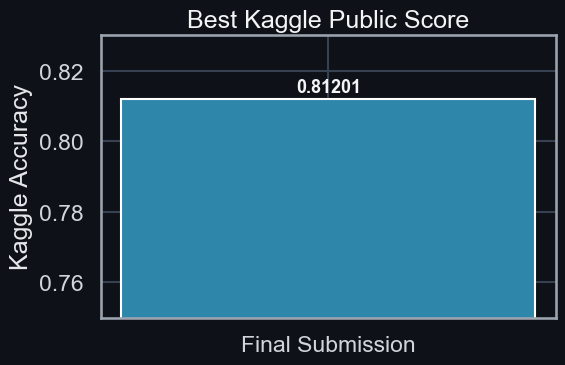

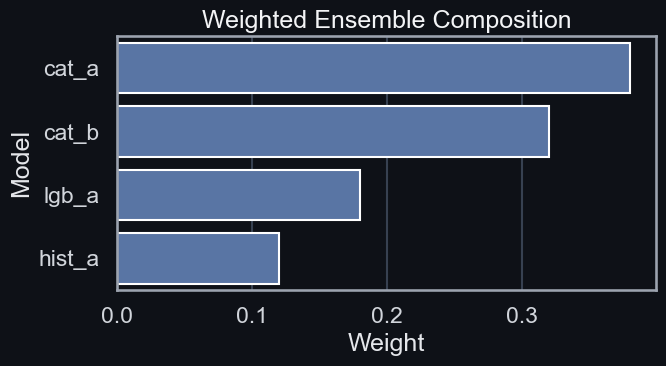

In [32]:
# BLOCK 09.5 | Result Visualization for PPT

result_dir = CFG.output_dir / "result_figures"
result_dir.mkdir(parents=True, exist_ok=True)

# Final Kaggle score visualization
plt.figure(figsize=(6, 4))
plt.bar(["Final Submission"], [0.81201], color="#2E86AB")
plt.ylim(0.75, 0.83)
plt.ylabel("Kaggle Accuracy")
plt.title("Best Kaggle Public Score")
plt.text(0, 0.81201 + 0.002, "0.81201", ha="center", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(result_dir / "best_kaggle_score.png", dpi=300)
plt.show()

# Model ensemble weights
weights_df = pd.DataFrame({
    "Model": results["blend_names"],
    "Weight": results["blend_weights"]
}).sort_values("Weight", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=weights_df, x="Weight", y="Model")
plt.title("Weighted Ensemble Composition")
plt.xlabel("Weight")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig(result_dir / "ensemble_weights.png", dpi=300)
plt.show()

In [13]:
# ========= Standalone logging cell  =========
import logging, sys, time, os
from pathlib import Path
from contextlib import contextmanager

def setup_logger(log_dir="outputs", log_name="spaceship_run.log", level=logging.INFO):
    Path(log_dir).mkdir(parents=True, exist_ok=True)
    log_path = Path(log_dir) / log_name

    logger = logging.getLogger("spaceship")
    logger.setLevel(level)
    logger.propagate = False

    # avoid duplicated handlers in notebook reruns
    if logger.handlers:
        for h in list(logger.handlers):
            logger.removeHandler(h)

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s", datefmt="%Y-%m-%d %H:%M:%S")

    fh = logging.FileHandler(log_path, encoding="utf-8")
    fh.setLevel(level)
    fh.setFormatter(fmt)

    sh = logging.StreamHandler(sys.stdout)
    sh.setLevel(level)
    sh.setFormatter(fmt)

    logger.addHandler(fh)
    logger.addHandler(sh)

    logger.info(f"Logger ready -> {log_path.resolve()}")
    logger.info(f"CPU count: {os.cpu_count()}")
    return logger

log = setup_logger()

@contextmanager
def log_section(title: str):
    t0 = time.perf_counter()
    log.info(f"[START] {title}")
    try:
        yield
    except Exception as e:
        log.exception(f"[ERROR] {title}: {e}")
        raise
    finally:
        dt = time.perf_counter() - t0
        log.info(f"[END] {title} | {dt:.2f}s")

2026-05-20 12:11:49 | INFO | Logger ready -> C:\Users\bruce\Desktop\workshop\outputs\spaceship_run.log
2026-05-20 12:11:49 | INFO | CPU count: 16


In [14]:
# BLOCK 10 | Optional Kaggle CLI submission

def submit_with_kaggle_cli(
    enable_submit: bool = CFG.enable_auto_submit,
    file_name: str | Path = CFG.submission_file,
    competition_name: str = CFG.competition_name,
    submission_message: str | None = CFG.submission_message,
):
    if not enable_submit:
        print('Automatic submission is disabled.')
        print('If you want auto submit, set CFG.enable_auto_submit = True and rerun this cell.')
        return None

    message = submission_message or datetime.now().strftime('%H:%M:%S')
    file_name = str(file_name)

    try:
        submit_cmd = [
            'kaggle', 'competitions', 'submit',
            '-c', competition_name,
            '-f', file_name,
            '-m', message,
        ]
        submit_run = subprocess.run(
            submit_cmd,
            check=True,
            capture_output=True,
            text=True,
        )
        submit_output = submit_run.stdout.strip() or submit_run.stderr.strip()
        print(submit_output or f'Submitted {file_name} to {competition_name} with message: {message}')

        status_cmd = ['kaggle', 'competitions', 'submissions', '-c', competition_name]
        status_run = subprocess.run(
            status_cmd,
            check=True,
            capture_output=True,
            text=True,
        )
        status_output = status_run.stdout.strip() or status_run.stderr.strip()
        if status_output:
            print(status_output)

    except FileNotFoundError:
        print('Automatic submission failed: kaggle CLI not found.')
    except subprocess.CalledProcessError as exc:
        error_text = ' '.join(part for part in [exc.stdout, exc.stderr] if part).strip() or str(exc)
        print('Automatic submission failed.')
        print(f'Error: {error_text}')

submit_with_kaggle_cli()

Automatic submission is disabled.
If you want auto submit, set CFG.enable_auto_submit = True and rerun this cell.
